   Unnamed: 0  work_year experience_level employment_type  \
0           0       2020               MI              FT   
1           1       2020               SE              FT   
2           2       2020               SE              FT   
3           3       2020               MI              FT   
4           4       2020               SE              FT   

                    job_title  salary salary_currency  salary_in_usd  \
0              Data Scientist   70000             EUR          79833   
1  Machine Learning Scientist  260000             USD         260000   
2           Big Data Engineer   85000             GBP         109024   
3        Product Data Analyst   20000             USD          20000   
4   Machine Learning Engineer  150000             USD         150000   

  employee_residence  remote_ratio company_location company_size  
0                 DE             0               DE            L  
1                 JP             0               JP            S  

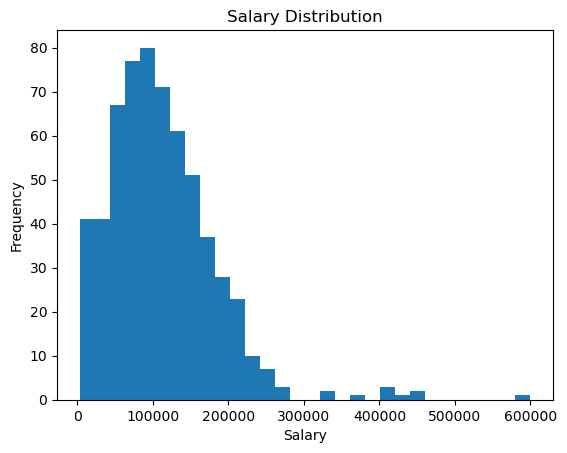

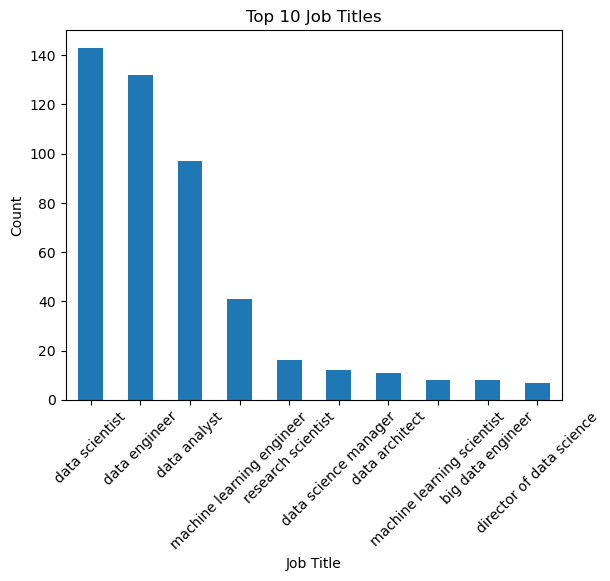

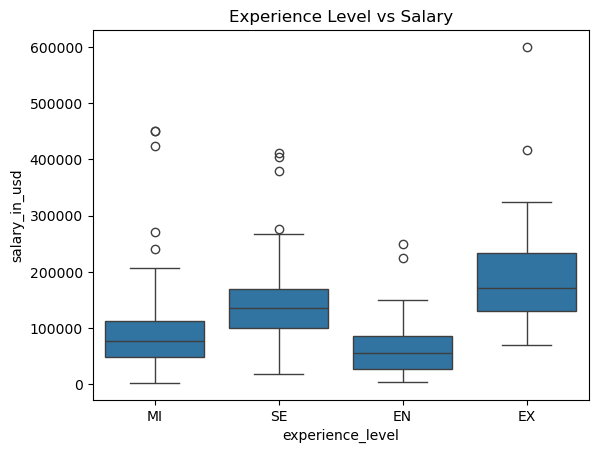

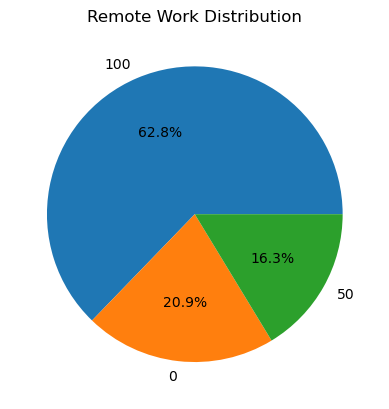

MAE: 40705.85176622476
R2 Score: 0.21186496106183428


In [1]:
# TASK 01: Loading Dataset
import pandas as pd

# Load dataset
df = pd.read_csv("ds_salaries.csv")

# Display first rows
print(df.head())

# Dataset information
print(df.info())

# Shape of dataset
print("Shape:", df.shape)

# Missing values
print(df.isnull().sum())

# Statistical summary
print(df.describe())

# Column names
print(df.columns)

#TASK 02: Data Cleaning And Preprocessing
# Checking duplicates
print("Duplicates:", df.duplicated().sum())

# Removing duplicates
df = df.drop_duplicates()

# Missing values
print(df.isnull().sum())

# Standardize column names
df.columns = df.columns.str.lower()

# Convert job title to lowercase
df['job_title'] = df['job_title'].str.lower()

# Final cleaned dataset
print(df.head())

#TASK 03: Exploratory Data Analysis (EDA)
# Average salary
print("Average Salary:", df['salary_in_usd'].mean())

# Highest paying job titles
print(df.groupby('job_title')['salary_in_usd']
      .mean()
      .sort_values(ascending=False)
      .head(10))

# Salary by experience level
print(df.groupby('experience_level')['salary_in_usd'].mean())

# Salary by remote ratio
print(df.groupby('remote_ratio')['salary_in_usd'].mean())

#TASK 04: Data Visualisation
import matplotlib.pyplot as plt

plt.hist(df['salary_in_usd'], bins=30)
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution")
plt.show()

top_jobs = df['job_title'].value_counts().head(10)

top_jobs.plot(kind='bar')

plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

import seaborn as sns

sns.boxplot(x='experience_level', y='salary_in_usd', data=df)

plt.title("Experience Level vs Salary")
plt.show()

df['remote_ratio'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Remote Work Distribution")
plt.ylabel("")
plt.show()

#TASK 05: Predictive Modelling
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'experience_level',
    'employment_type',
    'job_title',
    'company_size'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df[
    [
        'experience_level',
        'employment_type',
        'job_title',
        'company_size',
        'remote_ratio'
    ]
]

y = df['salary_in_usd']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, r2_score

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))